# Entrega Final ⭐
## Alumno= Panzeri Karen Magali

In [1]:
#Importo librerias
import pandas as pd

# **Importo Dataframes**

#VENTAS
###Importo el primer dataset de ventas y lo voy a nombrar como df_ventas

In [2]:
#Cargo el dataset con el enlace drive, debe estar compartido y no es necesario tenerlo en nuestro drive
link_ventas = "https://drive.google.com/file/d/1dpvV5iOAKyD7QZX8gwAZVZIefWGpnTKM/view?usp=sharing"
#extraemos el id del enlace dividiendo entre /d/ (no quedamos con el segundo fragmento) y luego en / (nos quedamos con el primer fragmento)
file_id_ventas= link_ventas.split('/d/')[1].split('/')[0]
# Con ese file_id generamos la url
url_ventas = f"https://drive.google.com/uc?id={file_id_ventas}"
# Finalmente lo importamos usando el método read_csv() con la url generada
df_ventas= pd.read_csv(url_ventas)

# MARKETING

In [3]:
#Cargo el dataset con el enlace drive, debe estar compartido y no es necesario tenerlo en nuestro drive
link_marketing = "https://drive.google.com/file/d/1NV-ICitmc8HQjhNEuUcgKqvajoBbNBT5/view?usp=drive_link"
#extraemos el id del enlace dividiendo entre /d/ (no quedamos con el segundo fragmento) y luego en / (nos quedamos con el primer fragmento)
file_id_marketing = link_marketing.split('/d/')[1].split('/')[0]
# Con ese file_id generamos la url
url_marketing = f"https://drive.google.com/uc?id={file_id_marketing}"
# Finalmente lo importamos usando el método read_csv() con la url generada
df_marketing= pd.read_csv(url_marketing)

# CLIENTES

In [4]:
#Cargo el dataset con el enlace drive, debe estar compartido y no es necesario tenerlo en nuestro drive
link_clientes = "https://drive.google.com/file/d/1NV-ICitmc8HQjhNEuUcgKqvajoBbNBT5/view?usp=drive_link"
#extraemos el id del enlace dividiendo entre /d/ (no quedamos con el segundo fragmento) y luego en / (nos quedamos con el primer fragmento)
file_id_clientes = link_clientes.split('/d/')[1].split('/')[0]
# Con ese file_id generamos la url
url_clientes = f"https://drive.google.com/uc?id={file_id_clientes}"
# Finalmente lo importamos usando el método read_csv() con la url generada
df_clientes= pd.read_csv(url_clientes)

# **Etapa 1**
# 1 EDA (Análisis Exploratorio de datos)

###1.   .info()
###2.   .head()
###3. .describe()
###4. .duplicated()

#EDA_VENTAS

##1.1 .Info ()

Comenzamos con el método .info() el cual nos da cantidad de filas y columnas, nombre de las columnas, valores nulos tipo de datos, etc:


In [5]:

df_ventas.info()

# El .info() de df_ventas nos indica que hay 3035 entradas (filas) y 6 columnas.
#Ninguna con valores nulos, pero con tipos de datos incorrectos (e.g., precio como objeto)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035 entries, 0 to 3034
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venta     3035 non-null   int64  
 1   producto     3035 non-null   object 
 2   precio       3033 non-null   object 
 3   cantidad     3033 non-null   float64
 4   fecha_venta  3035 non-null   object 
 5   categoria    3035 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 142.4+ KB


1.2  .head()

Método head nos devuelve los primeros 5 registros, .tail() devuelve los ultimos y .sample() aleatorio

In [6]:
df_ventas.head()

,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,$69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,$105.10,5.0,02/01/2024,Decoración
2,1156,Secadora,$97.96,3.0,02/01/2024,Electrodomésticos
3,1372,Heladera,$114.35,8.0,02/01/2024,Electrodomésticos
4,1546,Secadora,$106.21,4.0,02/01/2024,Electrodomésticos


##1.3 .describe()
Solo toma los valores numericos, la primer columna corresponde al id de la venta y la segunda a la cantidad.

In [7]:
df_ventas.describe()

,id_venta,cantidad
count,3035.000000,3033.000000
mean,1499.851400,6.496538
std,866.465379,3.457250
min,1.000000,1.000000
25%,748.500000,3.000000
50%,1502.000000,7.000000
75%,2249.500000,9.000000
max,3000.000000,12.000000


In [8]:
#También podemos incluir las variables Categoricas
df_ventas.describe(include='object')
#aquí vemos que el top de venta de producto es la Lámpara de Mesa y nos damos cuenta que interpreta precio como objeto y que tiene
#distintas formas de aparecer, lo mismo con la fecha.

,producto,precio,fecha_venta,categoria
count,3035,3033,3035,3035
unique,30,2590,364,3
top,Lámpara de mesa,$76.32,06/04/2024,Decoración
freq,181,5,24,1015


In [9]:
#quiero ver los productos que hay y categoría
df_ventas[['producto', 'categoria']].value_counts()

,,count
producto,categoria,
Lámpara de mesa,Decoración,181
Auriculares,Electrónica,147
Microondas,Electrodomésticos,135
Cafetera,Electrodomésticos,118
Laptop,Electrónica,104
Secadora,Electrodomésticos,103
Jarrón decorativo,Decoración,102
Rincón de plantas,Decoración,102
Smartphone,Electrónica,102


##1.4 .duplicated()
Cantidad de duplicados presentes en el dataset

In [10]:
df_ventas.duplicated().sum()

np.int64(35)

In [11]:
df_ventas[df_ventas.duplicated(keep= False)]

,id_venta,producto,precio,cantidad,fecha_venta,categoria
820,56,Cortinas,$66.24,5.0,05/04/2024,Decoración
821,421,Lámpara de mesa,$114.83,9.0,05/04/2024,Decoración
822,424,Jarrón decorativo,$87.94,2.0,05/04/2024,Decoración
823,1868,Cafetera,$62.23,1.0,05/04/2024,Electrodomésticos
824,2545,Auriculares,$32.81,11.0,05/04/2024,Electrónica
...,...,...,...,...,...,...
885,1381,Freidora eléctrica,$38.12,2.0,08/04/2024,Electrodomésticos
886,2365,Auriculares,$92.91,11.0,08/04/2024,Electrónica
887,2486,Laptop,$124.95,11.0,08/04/2024,Electrónica
888,2506,Laptop,$34.74,1.0,08/04/2024,Electrónica


# 1.4 .isnull()
conteo de nulos por columna, el .info nos daba unicamente el conteo sin los nulos

In [12]:
df_ventas.isnull().sum()


,0
id_venta,0
producto,0
precio,2
cantidad,2
fecha_venta,0
categoria,0


In [13]:
#vemos qué filas son las que presentan estos Nan
df_ventas[df_ventas.isnull().any(axis=1)]

,id_venta,producto,precio,cantidad,fecha_venta,categoria
136,627,Elementos de cerámica,NaN,NaN,17/01/2024,Decoración
139,2171,Parlantes Bluetooth,NaN,NaN,17/01/2024,Electrónica


# PARA CLIENTES Y MARKETING LO REALIZO AUTOMATIZADO

In [14]:
def resumen_eda(df):
    print("📊 Dimensiones del dataset")
    print(f"Filas: {df.shape[0]}")
    print(f"Columnas: {df.shape[1]}")
    print("-" * 40)

    print("\n🔎 Tipos de datos")
    print(df.dtypes)
    print("-" * 40)

    print("\n🔎 Primeros registros")
    print(df.head(2))
    print("-" * 40)

    print("\n📈 Estadísticas descriptivas")
    print(df.describe(include='number'))
    print("-" * 40)

    print("\n📈 Estadísticas descriptivas")
    try:
        print(df.describe(include='object'))
    except:
      print("No hay variables categóricas")
    print("-" * 40)

    print("\n⚠️ Valores nulos por columna")
    nulos = df.isnull().sum()
    if (nulos > 0).any():
        print(nulos[nulos > 0].sort_values(ascending=False))
    else:
        print("No hay valores nulos en el DataFrame (0 en todas las columnas)")
    print("-" * 40)

    print("\n📌 Porcentaje de nulos por columna")
    porcentaje_nulos = df.isnull().mean() * 100
    if (porcentaje_nulos > 0).any():
        print(porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False))
    else:
        print("No hay valores nulos (0% en todas las columnas)")
    print("-" * 40)

    print("\n🔁 Registros duplicados")
    duplicados = df.duplicated().sum()
    print(f"Cantidad de duplicados: {duplicados}")
    print("-" * 40)

In [15]:
resumen_eda(df_clientes)

📊 Dimensiones del dataset
Filas: 90
Columnas: 6
----------------------------------------

🔎 Tipos de datos
id_campanha       int64
producto         object
canal            object
costo           float64
fecha_inicio     object
fecha_fin        object
dtype: object
----------------------------------------

🔎 Primeros registros
   id_campanha         producto canal  costo fecha_inicio   fecha_fin
0           74  Adorno de pared    TV   4.81   20/03/2024  03/05/2024
1           12           Tablet  RRSS   3.40   26/03/2024  13/05/2024
----------------------------------------

📈 Estadísticas descriptivas
       id_campanha      costo
count    90.000000  90.000000
mean     45.500000   4.928667
std      26.124701   0.947750
min       1.000000   2.950000
25%      23.250000   4.372500
50%      45.500000   4.900000
75%      67.750000   5.562500
max      90.000000   7.390000
----------------------------------------

📈 Estadísticas descriptivas
               producto canal fecha_inicio   fecha_f

In [16]:
resumen_eda(df_marketing)

📊 Dimensiones del dataset
Filas: 90
Columnas: 6
----------------------------------------

🔎 Tipos de datos
id_campanha       int64
producto         object
canal            object
costo           float64
fecha_inicio     object
fecha_fin        object
dtype: object
----------------------------------------

🔎 Primeros registros
   id_campanha         producto canal  costo fecha_inicio   fecha_fin
0           74  Adorno de pared    TV   4.81   20/03/2024  03/05/2024
1           12           Tablet  RRSS   3.40   26/03/2024  13/05/2024
----------------------------------------

📈 Estadísticas descriptivas
       id_campanha      costo
count    90.000000  90.000000
mean     45.500000   4.928667
std      26.124701   0.947750
min       1.000000   2.950000
25%      23.250000   4.372500
50%      45.500000   4.900000
75%      67.750000   5.562500
max      90.000000   7.390000
----------------------------------------

📈 Estadísticas descriptivas
               producto canal fecha_inicio   fecha_f

# **Etapa 2**
# Preprocesamiento y Limpieza de Datos

In [17]:
#Hacemos copia de dataframes
df_clientes_copy=df_clientes.copy()
df_marketing_copy=df_marketing.copy()
df_ventas_copy=df_ventas.copy()


# **Ventas**
Del EDA se desprende que hay que realizar los siguie tes tratamientos:
-

1.   quitar $ de precio y pasar a float
2.   fecha pasar a datetime
3.   quitar nulos= 2
4.   quitar duplicados = 35
5. renombrar precio a precio_unitario para luego multiplicar por cantidad y sea precio nueva columna

In [18]:
#cambio nombre de columna
df_ventas_copy.rename(columns={'precio':'precio_unitario'}, inplace=True)

In [19]:
#creo una columna nueva de precio unitario quitando $ con metodo .str.replace()
df_ventas_copy['precio_unitario']= df_ventas_copy['precio_unitario'].str.replace('$', '')
df_ventas_copy.head()

,id_venta,producto,precio_unitario,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,105.10,5.0,02/01/2024,Decoración
2,1156,Secadora,97.96,3.0,02/01/2024,Electrodomésticos
3,1372,Heladera,114.35,8.0,02/01/2024,Electrodomésticos
4,1546,Secadora,106.21,4.0,02/01/2024,Electrodomésticos


In [20]:
#Paso precio a float
df_ventas_copy ['precio_unitario']= pd.to_numeric(df_ventas_copy['precio_unitario'], errors='coerce')
df_ventas_copy['precio_unitario'].dtype

dtype('float64')

In [21]:
df_ventas_copy['fecha_venta']= pd.to_datetime(df_ventas_copy['fecha_venta'], dayfirst= True, errors='coerce')
df_ventas_copy['fecha_venta']= pd.to_datetime(df_ventas_copy['fecha_venta'], format= '%d%m%Y', errors='coerce')
df_ventas_copy.head(10)

,id_venta,producto,precio_unitario,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,69.94,5.0,2024-01-02,Decoración
1,811,Lámpara de mesa,105.10,5.0,2024-01-02,Decoración
2,1156,Secadora,97.96,3.0,2024-01-02,Electrodomésticos
3,1372,Heladera,114.35,8.0,2024-01-02,Electrodomésticos
4,1546,Secadora,106.21,4.0,2024-01-02,Electrodomésticos
5,1697,Horno eléctrico,35.35,9.0,2024-01-02,Electrodomésticos
6,1710,Plancha de vapor,65.43,2.0,2024-01-02,Electrodomésticos
7,2959,Proyector,88.17,9.0,2024-01-02,Electrónica
8,318,Rincón de plantas,79.86,11.0,2024-01-03,Decoración
9,419,Candelabro,66.11,8.0,2024-01-03,Decoración


In [22]:
#Elimino duplicados y nulos
df_ventas_copy.drop_duplicates(inplace=True)
df_ventas_copy.dropna(inplace=True)

In [23]:
#Cantidad a int
df_ventas_copy['cantidad']= df_ventas_copy['cantidad'].astype(int)
#chequeo todo lo anterior
resumen_eda(df_ventas_copy)

📊 Dimensiones del dataset
Filas: 2998
Columnas: 6
----------------------------------------

🔎 Tipos de datos
id_venta                    int64
producto                   object
precio_unitario           float64
cantidad                    int64
fecha_venta        datetime64[ns]
categoria                  object
dtype: object
----------------------------------------

🔎 Primeros registros
   id_venta           producto  precio_unitario  cantidad fecha_venta  \
0       792  Cuadro decorativo            69.94         5  2024-01-02   
1       811    Lámpara de mesa           105.10         5  2024-01-02   

    categoria  
0  Decoración  
1  Decoración  
----------------------------------------

📈 Estadísticas descriptivas
          id_venta  precio_unitario     cantidad
count  2998.000000      2998.000000  2998.000000
mean   1500.567712        75.291318     6.502668
std     866.225183        28.736008     3.455107
min       1.000000        26.000000     1.000000
25%     751.250000        5

# **Marketing**
##Transformaicones
Del EDA se desprende que hay que realizar los siguientes tratamientos:
1. Tipos de datos: convertir fecha_inicio y fecha_fin a datetime
2. Revisar que fecha_fin > fecha_inicio


In [24]:
df_marketing_copy['fecha_fin'] = pd.to_datetime(df_marketing_copy['fecha_fin'], format='%d/%m/%Y')
df_marketing_copy['fecha_inicio'] = pd.to_datetime(df_marketing_copy['fecha_inicio'], format='%d/%m/%Y')
df_marketing_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_campanha   90 non-null     int64         
 1   producto      90 non-null     object        
 2   canal         90 non-null     object        
 3   costo         90 non-null     float64       
 4   fecha_inicio  90 non-null     datetime64[ns]
 5   fecha_fin     90 non-null     datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(2)
memory usage: 4.3+ KB


In [25]:
df_marketing_copy["duracion"] = df_marketing_copy["fecha_fin"] - df_marketing_copy["fecha_inicio"]
#Filtramos los posibles negativos
df_marketing_copy[df_marketing_copy["duracion"] < pd.Timedelta(0)]
df_marketing_copy

,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin,duracion
0,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,44 days
1,12,Tablet,RRSS,3.40,2024-03-26,2024-05-13,48 days
2,32,Lámpara de mesa,Email,5.54,2024-03-28,2024-04-20,23 days
3,21,Smartphone,RRSS,6.37,2024-03-29,2024-05-16,48 days
4,58,Alfombra,Email,4.25,2024-03-31,2024-05-05,35 days
...,...,...,...,...,...,...,...
85,70,Aspiradora,TV,3.06,2024-12-13,2024-12-29,16 days
86,89,Televisor,TV,4.98,2024-12-13,2025-02-08,57 days
87,68,Rincón de plantas,TV,5.81,2024-12-17,2025-02-14,59 days
88,33,Secadora,Email,3.80,2024-12-20,2025-01-07,18 days


# Agrupaciones y Agregaciones
##Crear Tabla a partir de Ventas que muestre productos de alto rendimiento

In [26]:
#creo columna de venta neta (producto entre precio unitario y cantidad)
df_ventas_copy['venta_neta']= df_ventas_copy['precio_unitario']* df_ventas_copy['cantidad']
#chequeo que se haya creado la columna
df_ventas_copy.head(2)

,id_venta,producto,precio_unitario,cantidad,fecha_venta,categoria,venta_neta
0,792,Cuadro decorativo,69.94,5,2024-01-02,Decoración,349.7
1,811,Lámpara de mesa,105.10,5,2024-01-02,Decoración,525.5


In [27]:
df_ventas_altorend= df_ventas_copy.groupby(['producto'], as_index=False)['venta_neta'].sum()
df_ventas_altorend
#candelabro es el producto con menos rendimiento, lámpara de mesa el que más rindió.

,producto,venta_neta
0,Adorno de pared,48093.49
1,Alfombra,44773.06
2,Aspiradora,50085.86
3,Auriculares,74175.58
4,Batidora,50979.20
5,Cafetera,59607.31
6,Candelabro,11128.80
7,Consola de videojuegos,46174.41
8,Cortinas,44865.03
9,Cuadro decorativo,54297.60


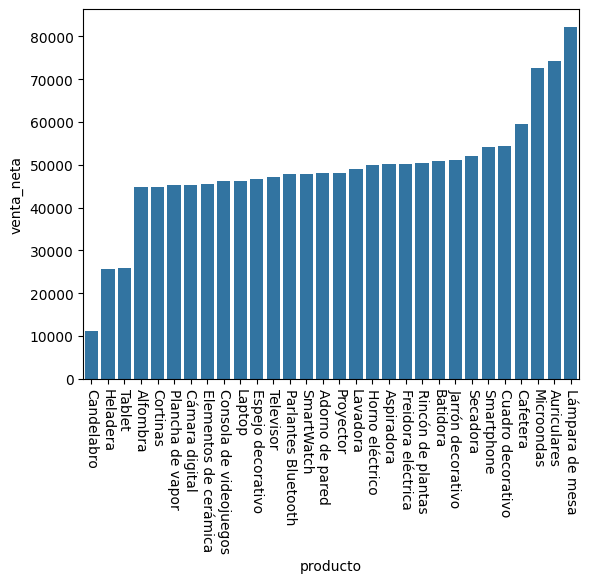

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
df_ventas_altorend= df_ventas_altorend.sort_values(by= 'venta_neta', ascending= True)
sns.barplot(data= df_ventas_altorend, x= 'producto', y= 'venta_neta')
plt.xticks(rotation= 270)
plt.show()

In [29]:
#separamos los productos hasta el quartil 90 y luego mostramos el 10% por encima de ese 90
from numpy import quantile
quantile_90= df_ventas_altorend['venta_neta'].quantile(0.9)
df_ventas_altorend_10= df_ventas_altorend[df_ventas_altorend['venta_neta']> quantile_90]
df_ventas_altorend_10.sort_values(by='venta_neta', ascending= False)

,producto,venta_neta
19,Lámpara de mesa,82276.38
3,Auriculares,74175.58
20,Microondas,72562.89


##Ventas por categoría más amplias de productos

<Axes: xlabel='categoria', ylabel='venta_neta'>

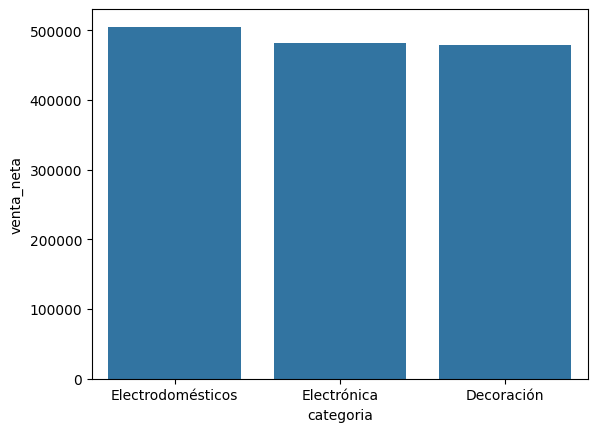

In [30]:
df_ventas_categoria= df_ventas_copy.groupby(['categoria'], as_index=False) ['venta_neta']. sum()
df_ventas_categoria=df_ventas_categoria.sort_values(by='venta_neta', ascending= False)
sns.barplot(data= df_ventas_categoria, x='categoria', y= 'venta_neta')

In [31]:
#Agrupaciones de Marketing
df_marketing_copy.head(2)
df_marketing_campaña= df_marketing_copy.groupby(['id_campanha', 'producto', 'canal'], as_index=False)['costo'].sum()
df_marketing_campaña

,id_campanha,producto,canal,costo
0,1,Cuadro decorativo,RRSS,5.27
1,2,Lámpara de mesa,RRSS,5.88
2,3,Secadora,RRSS,5.10
3,4,Heladera,RRSS,4.53
4,5,Horno eléctrico,RRSS,5.16
...,...,...,...,...
85,86,Microondas,TV,4.25
86,87,Batidora,TV,6.28
87,88,Alfombra,TV,7.39
88,89,Televisor,TV,4.98


In [32]:
df_ventas_copy.sort_values(by='producto')

,id_venta,producto,precio_unitario,cantidad,fecha_venta,categoria,venta_neta
1513,410,Adorno de pared,109.64,3,2024-06-21,Decoración,328.92
2463,620,Adorno de pared,92.16,4,2024-10-21,Decoración,368.64
699,780,Adorno de pared,79.13,7,2024-03-21,Decoración,553.91
257,50,Adorno de pared,83.10,5,2024-01-31,Decoración,415.50
112,260,Adorno de pared,101.48,9,2024-01-15,Decoración,913.32
...,...,...,...,...,...,...,...
1317,2652,Televisor,74.49,4,2024-05-25,Electrónica,297.96
220,2252,Televisor,89.27,8,2024-01-26,Electrónica,714.16
643,2082,Televisor,55.66,3,2024-03-15,Electrónica,166.98
1703,2991,Televisor,92.33,4,2024-07-15,Electrónica,369.32


In [33]:
df_marketing_copy.sort_values(by='producto')

,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin,duracion
0,74,Adorno de pared,TV,4.81,2024-03-20,2024-05-03,44 days
8,44,Adorno de pared,Email,5.08,2024-04-13,2024-05-10,27 days
70,14,Adorno de pared,RRSS,4.16,2024-10-22,2024-12-21,60 days
84,28,Alfombra,RRSS,5.82,2024-11-27,2025-01-08,42 days
4,58,Alfombra,Email,4.25,2024-03-31,2024-05-05,35 days
...,...,...,...,...,...,...,...
32,72,Tablet,TV,4.90,2024-07-08,2024-09-03,57 days
1,12,Tablet,RRSS,3.40,2024-03-26,2024-05-13,48 days
81,59,Televisor,Email,4.19,2024-11-20,2025-01-19,60 days
16,29,Televisor,RRSS,3.96,2024-05-17,2024-06-28,42 days


In [34]:
#Antes de hacer el merge tengo que agrupar por  columna "producto" del datagrame marketing y sacar el costo total por cada categoria.
#Si no hago esto me va a triplicar las columnas cuando haga el merge
df_mark_filt= df_marketing_copy.groupby(['producto'], as_index=False)['costo'].sum()

#Ahora hago merge, va a enocntrar un item de producto en marketing
ventas_mark= pd.merge(df_ventas_copy, df_mark_filt, on= 'producto', how='left')
ventas_mark.sort_values(by= ['venta_neta'], ascending= False)
#Resultado:
#Vemos que el costo mas alto de campaña se lo llevó el producto Cafetera, el cual es el quinto producto en dejar mayor ventas netas
#La venta neta más alta la tiene la lámpara de mesa, lampara de mesa posee el puesto 19 de campaña mas cara de marketing

,id_venta,producto,precio_unitario,cantidad,fecha_venta,categoria,venta_neta,costo
548,2063,Smartphone,124.01,12,2024-03-05,Electrónica,1488.12,15.80
875,1109,Batidora,123.83,12,2024-04-11,Electrodomésticos,1485.96,15.28
846,2373,Smartphone,123.60,12,2024-04-07,Electrónica,1483.20,15.80
2308,2703,Smartphone,123.40,12,2024-10-03,Electrónica,1480.80,15.80
511,1569,Batidora,122.02,12,2024-02-29,Electrodomésticos,1464.24,15.28
...,...,...,...,...,...,...,...,...
935,1190,Plancha de vapor,29.68,1,2024-04-17,Electrodomésticos,29.68,14.12
179,442,Cuadro decorativo,29.17,1,2024-01-22,Decoración,29.17,15.85
1752,2561,Parlantes Bluetooth,28.91,1,2024-07-26,Electrónica,28.91,13.37
2843,2818,SmartWatch,27.83,1,2024-12-11,Electrónica,27.83,14.50


##Impacto de campaña en Redes Sociales (RRSS)

In [35]:
from os.path import join
df_marketing_copy["canal"].unique()
df_marketing_canal= df_marketing_copy[df_marketing_copy['canal']=='RRSS']
df_ventas_rrss=pd.merge(df_ventas_copy, df_marketing_canal, on='producto', how='left')
df_ventas_rrss.sort_values(by='venta_neta', ascending=False)

,id_venta,producto,precio_unitario,cantidad,fecha_venta,categoria,venta_neta,id_campanha,canal,costo,fecha_inicio,fecha_fin,duracion
548,2063,Smartphone,124.01,12,2024-03-05,Electrónica,1488.12,21,RRSS,6.37,2024-03-29,2024-05-16,48 days
875,1109,Batidora,123.83,12,2024-04-11,Electrodomésticos,1485.96,27,RRSS,4.52,2024-11-01,2024-12-08,37 days
846,2373,Smartphone,123.60,12,2024-04-07,Electrónica,1483.20,21,RRSS,6.37,2024-03-29,2024-05-16,48 days
2308,2703,Smartphone,123.40,12,2024-10-03,Electrónica,1480.80,21,RRSS,6.37,2024-03-29,2024-05-16,48 days
511,1569,Batidora,122.02,12,2024-02-29,Electrodomésticos,1464.24,27,RRSS,4.52,2024-11-01,2024-12-08,37 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...
935,1190,Plancha de vapor,29.68,1,2024-04-17,Electrodomésticos,29.68,6,RRSS,4.02,2024-09-24,2024-11-02,39 days
179,442,Cuadro decorativo,29.17,1,2024-01-22,Decoración,29.17,1,RRSS,5.27,2024-04-27,2024-06-04,38 days
1752,2561,Parlantes Bluetooth,28.91,1,2024-07-26,Electrónica,28.91,24,RRSS,6.00,2024-09-22,2024-10-26,34 days
2843,2818,SmartWatch,27.83,1,2024-12-11,Electrónica,27.83,25,RRSS,4.84,2024-11-23,2024-12-29,36 days


In [36]:
#Chequeamos que el valor de venta neta no se haya dupli o triplicado y siga igual luego del merge
df_ventas_copy["venta_neta"].sum()

np.float64(1467093.52)

In [37]:
df_ventas_rrss['venta_neta'].sum()

np.float64(1467093.52)

In [38]:
#Agrgeamos una columna con fecha venta realizada o no en campaña de marketing, valor booleano
df_ventas_rrss['en_campanha']= ((df_ventas_rrss['fecha_venta'] >= df_ventas_rrss['fecha_inicio']) & (df_ventas_rrss['fecha_venta'] <= df_ventas_rrss['fecha_fin']))
df_ventas_rrss

,id_venta,producto,precio_unitario,cantidad,fecha_venta,categoria,venta_neta,id_campanha,canal,costo,fecha_inicio,fecha_fin,duracion,en_campanha
0,792,Cuadro decorativo,69.94,5,2024-01-02,Decoración,349.70,1,RRSS,5.27,2024-04-27,2024-06-04,38 days,False
1,811,Lámpara de mesa,105.10,5,2024-01-02,Decoración,525.50,2,RRSS,5.88,2024-05-30,2024-06-29,30 days,False
2,1156,Secadora,97.96,3,2024-01-02,Electrodomésticos,293.88,3,RRSS,5.10,2024-07-24,2024-08-30,37 days,False
3,1372,Heladera,114.35,8,2024-01-02,Electrodomésticos,914.80,4,RRSS,4.53,2024-05-31,2024-07-15,45 days,False
4,1546,Secadora,106.21,4,2024-01-02,Electrodomésticos,424.84,3,RRSS,5.10,2024-07-24,2024-08-30,37 days,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2993,1837,Horno eléctrico,104.12,9,2024-12-30,Electrodomésticos,937.08,5,RRSS,5.16,2024-08-22,2024-10-17,56 days,False
2994,2276,Laptop,85.27,9,2024-12-30,Electrónica,767.43,30,RRSS,4.68,2024-10-23,2024-11-24,32 days,False
2995,2696,Laptop,107.81,4,2024-12-30,Electrónica,431.24,30,RRSS,4.68,2024-10-23,2024-11-24,32 days,False
2996,2913,Smartphone,99.85,7,2024-12-30,Electrónica,698.95,21,RRSS,6.37,2024-03-29,2024-05-16,48 days,False


In [39]:
#Calculamos la venta neta y el costo de campaña para productos que se vendieron durante la campaña de marketing
ventas_campanha_activa= df_ventas_rrss[df_ventas_rrss['en_campanha']==True]

In [40]:
venta_campanha_activa_agg= ventas_campanha_activa.groupby(['en_campanha']).agg(venta_neta_agg= ('venta_neta', "sum"), costo_agg=('costo', 'sum'))
venta_campanha_activa_agg

,venta_neta_agg,costo_agg
en_campanha,,
True,125449.52,1341.44


In [41]:
#agregamos ROI como cociente entre venta neta y costo

venta_campanha_activa_agg['ROI']= venta_campanha_activa_agg['venta_neta_agg']/venta_campanha_activa_agg['costo_agg']
venta_campanha_activa_agg

,venta_neta_agg,costo_agg,ROI
en_campanha,,,
True,125449.52,1341.44,93.518547


In [42]:
ventas_rrss_agg= df_ventas_rrss.groupby(['en_campanha']).agg(venta_neta_sum=('venta_neta', 'sum'), cantidad_neto_sum= ('cantidad', 'sum'))
ventas_rrss_agg

,venta_neta_sum,cantidad_neto_sum
en_campanha,,
False,1341644.00,17838
True,125449.52,1657


Se observa que algunos productos con mayores ventas netas no necesariamente son los que tuvieron mayor inversión en marketing, como ocurre con “Lámpara de mesa”. En cambio, productos como “Cafetera” presentan costos de campaña altos, aunque no lideran las ventas. También se desprende que las campañas en RRSS tuvieron ventas asociadas durante períodos activos de campaña, permitiendo calcular un ROI positivo. El análisis muestra además la importancia de agrupar correctamente los datos antes de hacer merges, ya que uniones many-to-many duplicaban registros y alteraban los totales

#Etapa 3: Análisis de datos
###Estadistica descriptiva para el dataframe entero y filtrado por venta en campaña activa e inactiva

In [43]:
#Ventas totales sin filtrado
df_ventas_rrss.describe()

,id_venta,precio_unitario,cantidad,fecha_venta,venta_neta,id_campanha,costo,fecha_inicio,fecha_fin,duracion
count,2998.000000,2998.000000,2998.000000,2998,2998.000000,2998.000000,2998.000000,2998,2998,2998
mean,1500.567712,75.291318,6.502668,2024-06-26 21:57:02.281520896,489.357412,15.727819,5.094316,2024-08-10 10:19:36.784523008,2024-09-14 08:56:31.060706816,34 days 22:36:54.276184122
min,1.000000,26.000000,1.000000,2024-01-02 00:00:00,26.300000,1.000000,3.160000,2024-03-26 00:00:00,2024-05-13 00:00:00,15 days 00:00:00
25%,751.250000,50.030000,3.000000,2024-03-27 00:00:00,220.920000,8.000000,4.650000,2024-06-26 00:00:00,2024-07-15 00:00:00,27 days 12:00:00
50%,1500.500000,75.205000,7.000000,2024-06-24 00:00:00,418.065000,16.000000,5.160000,2024-08-14 00:00:00,2024-09-15 00:00:00,35 days 00:00:00
75%,2250.750000,100.067500,9.000000,2024-09-27 00:00:00,709.920000,23.000000,5.700000,2024-09-25 00:00:00,2024-10-26 00:00:00,42 days 00:00:00
max,3000.000000,124.970000,12.000000,2024-12-30 00:00:00,1488.120000,30.000000,7.160000,2024-12-29 00:00:00,2025-01-21 00:00:00,60 days 00:00:00
std,866.225183,28.736008,3.455107,NaN,334.281817,8.794808,0.872044,NaN,NaN,11 days 21:44:50.225320202


In [44]:
#Campaña Activa
ventas_campanha_activa[["precio_unitario", "cantidad", "venta_neta", "costo"]].describe()

,precio_unitario,cantidad,venta_neta,costo
count,264.000000,264.000000,264.000000,264.000000
mean,75.656288,6.276515,475.187576,5.081212
std,28.898842,3.454657,332.692146,0.936574
min,26.200000,1.000000,27.830000,3.160000
25%,52.035000,3.000000,217.705000,4.520000
50%,74.965000,6.000000,401.775000,5.190000
75%,102.722500,9.000000,697.095000,5.820000
max,124.140000,12.000000,1483.200000,7.160000


In [45]:
#CApaña inactiva
ventas_campanha_inactiva= df_ventas_rrss[df_ventas_rrss['en_campanha']==False]
ventas_campanha_inactiva[["precio_unitario", "cantidad", "venta_neta", "costo"]].describe()

,precio_unitario,cantidad,venta_neta,costo
count,2734.000000,2734.000000,2734.000000,2734.000000
mean,75.256075,6.524506,490.725677,5.095582
std,28.725304,3.454998,334.463725,0.865730
min,26.000000,1.000000,26.300000,3.160000
25%,49.882500,3.000000,221.685000,4.650000
50%,75.285000,7.000000,418.830000,5.160000
75%,99.780000,10.000000,710.745000,5.700000
max,124.970000,12.000000,1488.120000,7.160000


#Histograma
##Vamos a graficar grafico de barras de ventas en campaña activa e inactiva


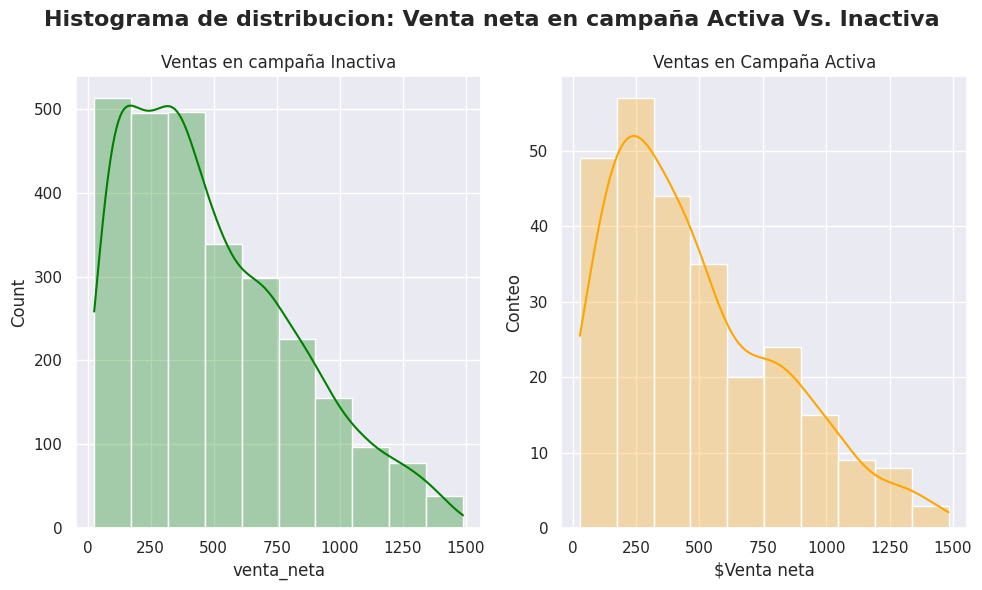

In [46]:
#Tmaño del gráfico y estilo
plt.figure(figsize=(10,6))
sns.set_theme(style='whitegrid', palette='muted')

#Titulo
plt.suptitle('Histograma de distribucion: Venta neta en campaña Activa Vs. Inactiva', fontsize=16, fontweight='bold')
sns.set_theme(palette="pastel")
# Histograma ventas fueran de campana
plt.subplot(1,2,1) # 1 fila 2 columnas - segundo bloque
sns.histplot(ventas_campanha_inactiva["venta_neta"], kde=True, bins=10, color='green', alpha=0.3)

plt.title("Ventas en campaña Inactiva")


# Histograma ventas en campanha
plt.subplot(1,2,2) # 1 fila 2 columnas - primer bloque
sns.histplot(ventas_campanha_activa["venta_neta"], kde=True, bins=10, color='orange', alpha=0.3)
plt.title("Ventas en Campaña Activa")
plt.ylabel('Conteo')
plt.xlabel('$Venta neta')


plt.ylabel('Conteo')
plt.xlabel('$Venta neta')
plt.tight_layout()

plt.show()

#Boxplots
##Gráficos Caja y Bigote, primero usamos mismo lienzo, luego hacemos subplots

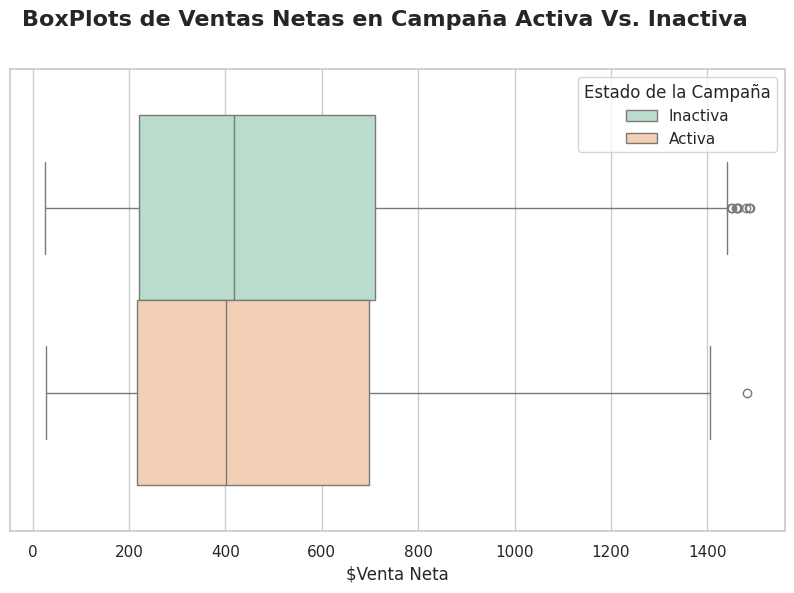

In [47]:
#mismo lienzo
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", palette="muted")

# Título general
plt.suptitle('BoxPlots de Ventas Netas en Campaña Activa Vs. Inactiva',
    fontsize=16,
    fontweight="bold"
)

sns.boxplot(
    data= df_ventas_rrss,
    x="venta_neta",
    hue="en_campanha",  palette="Pastel2"
)
plt.xlabel('$Venta Neta')
plt.legend(title='Estado de la Campaña',
           labels=['Inactiva', 'Activa'] )


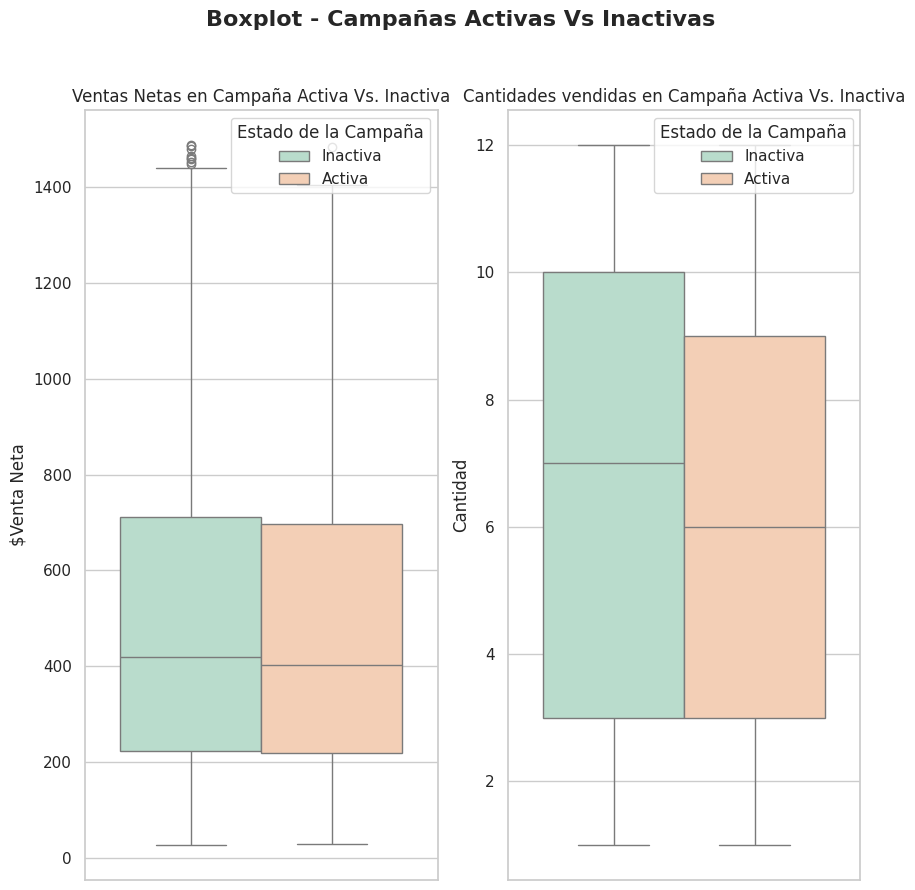

In [48]:
#BoxPlots de Cantidades vs Ventas neta en campaña activa e inactiva
plt.figure(figsize=(10, 10))
sns.set_theme(style="whitegrid", palette="muted")

# Título general
plt.suptitle(
    "Boxplot - Campañas Activas Vs Inactivas",
    fontsize=16,
    fontweight="bold"
)

# Histograma ventas en campana
plt.subplot(1,2,1)
sns.boxplot(
    data=df_ventas_rrss,
    y="venta_neta",
    hue="en_campanha",palette="Pastel2"
)
plt.ylabel('$Venta Neta')
plt.legend(title='Estado de la Campaña',
           labels=['Inactiva', 'Activa'] )
plt.title("Ventas Netas en Campaña Activa Vs. Inactiva")

# Histograma ventas en campana
plt.subplot(1,2,2)
sns.boxplot(
    data= df_ventas_rrss,
    y="cantidad",
    hue="en_campanha",palette="Pastel2"
)
plt.ylabel('Cantidad')
plt.legend(title='Estado de la Campaña',
           labels=['Inactiva', 'Activa'] )
plt.title("Cantidades vendidas en Campaña Activa Vs. Inactiva")


plt.show()

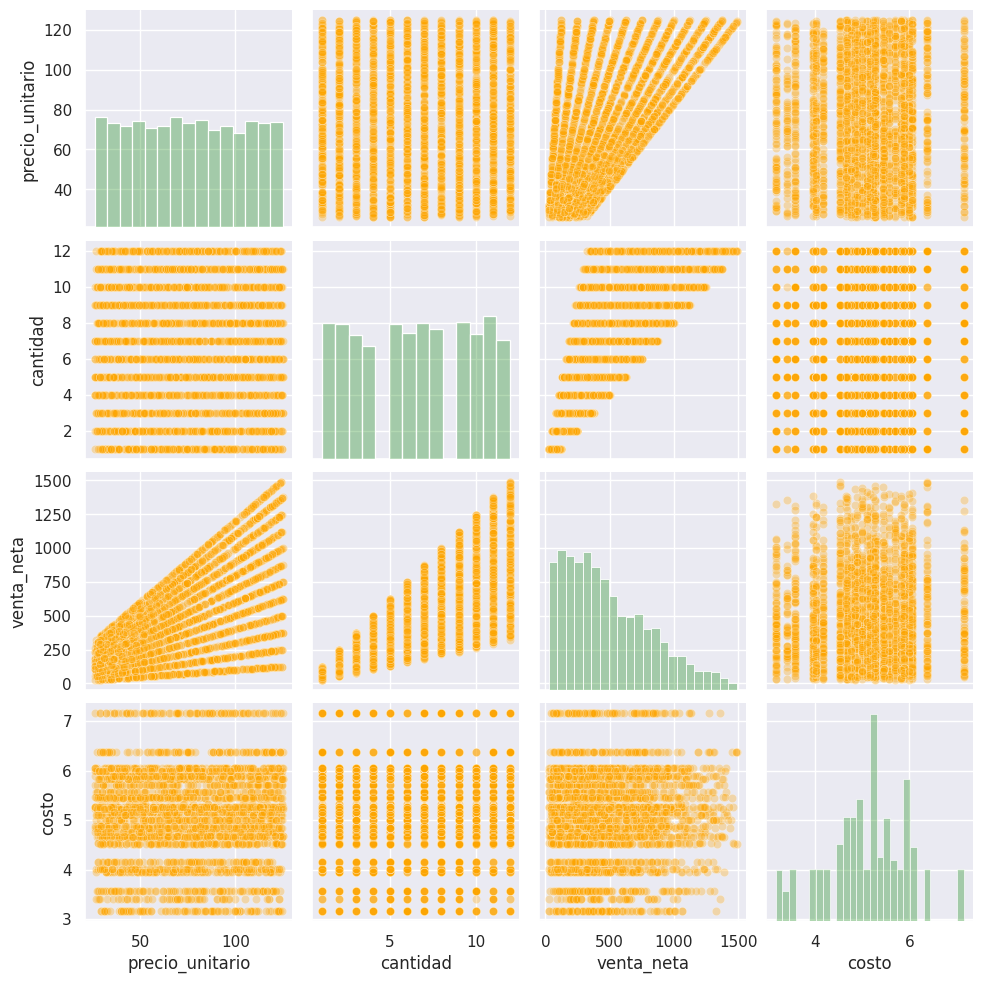

In [49]:
#Graficos de dispersión para visualizar correlación
sns.set_theme(palette="pastel")
sns.pairplot(
    df_ventas_rrss,
    vars=["precio_unitario", "cantidad", "venta_neta", "costo",],  plot_kws={"color": "orange", 'alpha':0.3}, diag_kws={"color": "green", 'alpha':0.3}
    )
sns.set_theme(palette="pastel")
plt.show()

#Correlación: valor de r y mapa de calor

In [50]:
corr_en_camapana = df_ventas_rrss[["precio_unitario", "cantidad", "venta_neta", "costo"]].corr()
corr_en_camapana

,precio_unitario,cantidad,venta_neta,costo
precio_unitario,1.000000,-0.002388,0.558846,0.016385
cantidad,-0.002388,1.000000,0.773009,0.006025
venta_neta,0.558846,0.773009,1.000000,0.022016
costo,0.016385,0.006025,0.022016,1.000000


<Axes: >

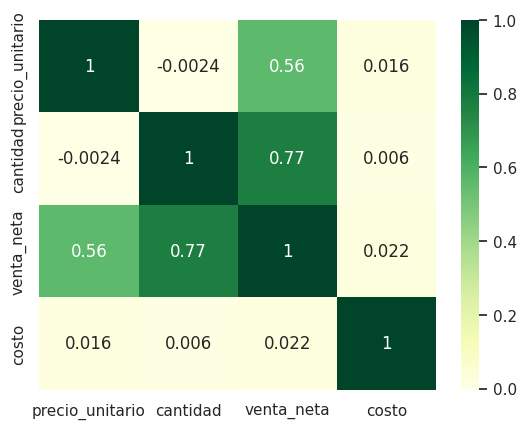

In [51]:
sns.heatmap(corr_en_camapana, annot=True, cmap="YlGn")

#Agrupaciones (groupby) y Agregaciones (agg), primerohacemos los calculos para los gráficos.

##Gráfico 1:Serie de tiempo

In [52]:
#Realizamos Agrupaciones (.groupby) Agregaciones (agg)
df_ventas_rrss['month']=df_ventas_rrss['fecha_venta'].dt.month
df_ventas_rrss

,id_venta,producto,precio_unitario,cantidad,fecha_venta,categoria,venta_neta,id_campanha,canal,costo,fecha_inicio,fecha_fin,duracion,en_campanha,month
0,792,Cuadro decorativo,69.94,5,2024-01-02,Decoración,349.70,1,RRSS,5.27,2024-04-27,2024-06-04,38 days,False,1
1,811,Lámpara de mesa,105.10,5,2024-01-02,Decoración,525.50,2,RRSS,5.88,2024-05-30,2024-06-29,30 days,False,1
2,1156,Secadora,97.96,3,2024-01-02,Electrodomésticos,293.88,3,RRSS,5.10,2024-07-24,2024-08-30,37 days,False,1
3,1372,Heladera,114.35,8,2024-01-02,Electrodomésticos,914.80,4,RRSS,4.53,2024-05-31,2024-07-15,45 days,False,1
4,1546,Secadora,106.21,4,2024-01-02,Electrodomésticos,424.84,3,RRSS,5.10,2024-07-24,2024-08-30,37 days,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2993,1837,Horno eléctrico,104.12,9,2024-12-30,Electrodomésticos,937.08,5,RRSS,5.16,2024-08-22,2024-10-17,56 days,False,12
2994,2276,Laptop,85.27,9,2024-12-30,Electrónica,767.43,30,RRSS,4.68,2024-10-23,2024-11-24,32 days,False,12
2995,2696,Laptop,107.81,4,2024-12-30,Electrónica,431.24,30,RRSS,4.68,2024-10-23,2024-11-24,32 days,False,12
2996,2913,Smartphone,99.85,7,2024-12-30,Electrónica,698.95,21,RRSS,6.37,2024-03-29,2024-05-16,48 days,False,12


In [53]:
df_ventas_rrss_time= df_ventas_rrss.groupby(['month', 'en_campanha'], as_index=False).agg(ventas_promedio=('venta_neta','mean'), suma_cantidades=('cantidad', 'sum'))
df_ventas_rrss_time.head(3)

,month,en_campanha,ventas_promedio,suma_cantidades
0,1,False,483.600709,1741
1,2,False,478.517903,1607
2,3,False,514.390267,1763


In [54]:
# generamos la columna estado a partir de en_campanha
df_ventas_rrss_time["estado"] = df_ventas_rrss_time["en_campanha"].map({
    True: "En campaña",
    False: "Fuera de campaña"
})

# drop de la columna inicial
df_ventas_rrss_time.drop(columns=["en_campanha"], inplace=True)

# ordenamos
df_ventas_rrss_time.sort_values(by="month", ascending=True, inplace=True)

In [55]:
#esto me va a permitir ver promedio de ventas y cantidades vendidas por mes
df_ventas_rrss_time

,month,ventas_promedio,suma_cantidades,estado
0,1,483.600709,1741,Fuera de campaña
1,2,478.517903,1607,Fuera de campaña
2,3,514.390267,1763,Fuera de campaña
3,3,669.633333,29,En campaña
4,4,467.237452,1613,Fuera de campaña
5,4,463.511875,102,En campaña
6,5,530.983249,1566,Fuera de campaña
7,5,470.637368,246,En campaña
8,6,482.694573,1272,Fuera de campaña
9,6,564.725000,154,En campaña


##Gráfico 2: Barplot1

In [56]:
#BarLPOT 1 VENTA PROMEDIO POR PRODUCTO
# Agregar venta_neta por producto, en_campanha
# para comparar ventas por efecto de camapana
df_ventas_rrss_prod = df_ventas_rrss.groupby(["producto", "en_campanha"], as_index=False).agg(
    venta_neta_avg = ("venta_neta", "mean")
)

In [57]:
# Generamos la columna estado que es mas representativa a en_campanha
df_ventas_rrss_prod["estado"] = df_ventas_rrss_prod["en_campanha"].map({
    True: "En campaña",
    False: "Fuera de campaña"
})

# drop de la columna anterior
df_ventas_rrss_prod.drop(columns=["en_campanha"], inplace=True)

# ordenamos
df_ventas_rrss_prod.sort_values(by="venta_neta_avg", ascending=False, inplace=True)

In [58]:
df_ventas_rrss_prod.head()

,producto,venta_neta_avg,estado
41,Microondas,805.875000,En campaña
29,Heladera,668.595000,En campaña
23,Elementos de cerámica,664.976667,En campaña
1,Adorno de pared,593.452727,En campaña
59,Televisor,571.997500,En campaña


##Gráfico 3: Barplot2

In [59]:
# Agregar venta_neta y costo por producto dentro de campa@a activa
# para evaluar los costos asociados a las ventas
df_ventas_rrss_prod_costo_activa = ventas_campanha_activa.groupby(["producto"], as_index=False).agg(
    venta_neta_avg = ("venta_neta", "mean"),
    costo_sum = ("costo", "sum")
)

df_ventas_rrss_prod_costo_activa.sort_values(by="venta_neta_avg", ascending=False, inplace=True)

In [60]:
df_ventas_rrss_prod_costo_activa.sort_values(by="producto", ascending=False).head()

,producto,venta_neta_avg,costo_sum
29,Televisor,571.997500,47.52
28,Tablet,418.701111,30.60
27,Smartphone,560.314375,101.92
26,SmartWatch,356.240000,19.36
25,Secadora,547.428000,25.50


In [61]:
# Convertir wide a long para el barplot
df_ventas_rrss_prod_costo_activa_long = pd.melt(
    df_ventas_rrss_prod_costo_activa,
    id_vars=["producto"],
    value_vars=["venta_neta_avg", "costo_sum"],
    var_name="metrica",
    value_name="valor"
)


In [62]:
df_ventas_rrss_prod_costo_activa_long.sort_values(by="producto", ascending=False).head(3)

,producto,metrica,valor
4,Televisor,venta_neta_avg,571.997500
34,Televisor,costo_sum,47.520000
21,Tablet,venta_neta_avg,418.701111


#Visualización de los gráficos


*   Serie temporal
*   Barplot1
*   Barplot 2



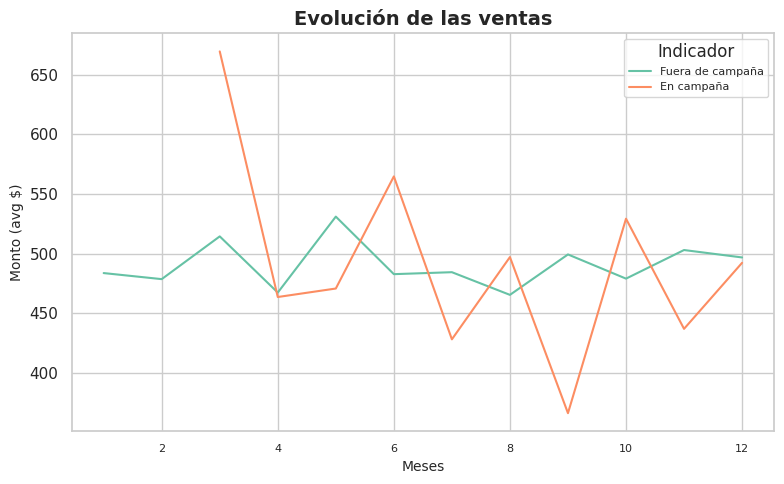

In [63]:
# SERIE TEMPORAL

#Estilo y paleta
sns.set_theme(style="whitegrid", palette="Set2")
plt.figure(figsize=(8,5))

# Plot
sns.lineplot(
    data=df_ventas_rrss_time,
    x="month",
    y="ventas_promedio",
    hue="estado"
)

# Personalización
plt.title("Evolución de las ventas", fontsize=14, weight="bold")
plt.xlabel("Meses", fontsize=10)
plt.ylabel("Monto (avg $)", fontsize=10)
plt.xticks(fontsize=8)

plt.legend(title="Indicador", fontsize=8)
plt.tight_layout()
plt.show()

In [65]:
#BARPLOT 1

# Tengo tres ordenamientos distintos para visualizar en el gráfico
orden1 = (
    df_ventas_rrss_prod
    .sort_values("producto", ascending=True)["producto"]
)

orden2 = (
    df_ventas_rrss_prod
    .query("estado == 'En campaña'")
    .sort_values("venta_neta_avg", ascending=False)["producto"]
)

orden3 = (
    df_ventas_rrss_prod
    .pivot(index="producto",
           columns="estado",
           values="venta_neta_avg")
    .assign(
        diferencia=lambda df: df["En campaña"] - df["Fuera de campaña"]
    )
    .sort_values("diferencia", ascending=False)
    .index
)

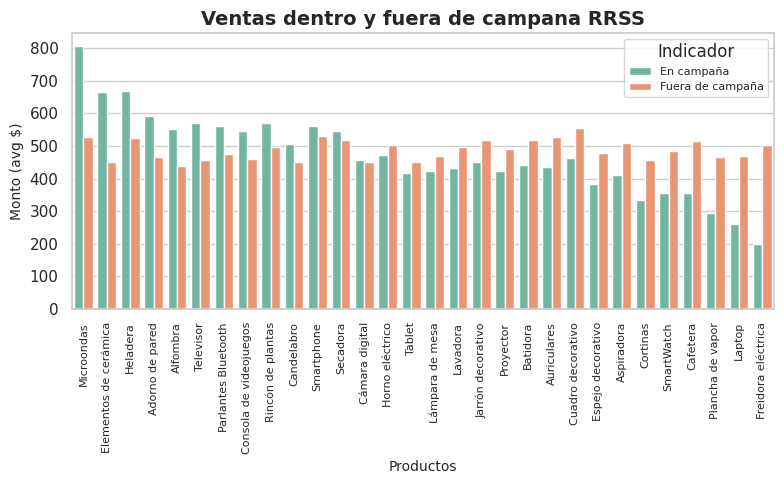

In [66]:
# Estilo y paleta
sns.set_theme(style="whitegrid", palette="Set2")
plt.figure(figsize=(8,5))

# Plot (considerar posibles ordenamientos orden 1, 2 y 3 ver siguiente bloque de código)
sns.barplot(
    data=df_ventas_rrss_prod,
    x="producto",
    y="venta_neta_avg",
    hue="estado",
    order=orden3
)

# Personalización
plt.title("Ventas dentro y fuera de campana RRSS", fontsize=14, weight="bold")
plt.xlabel("Productos", fontsize=10)
plt.ylabel("Monto (avg $)", fontsize=10)
plt.xticks(rotation=90, fontsize=8)

plt.legend(title="Indicador", fontsize=8)
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

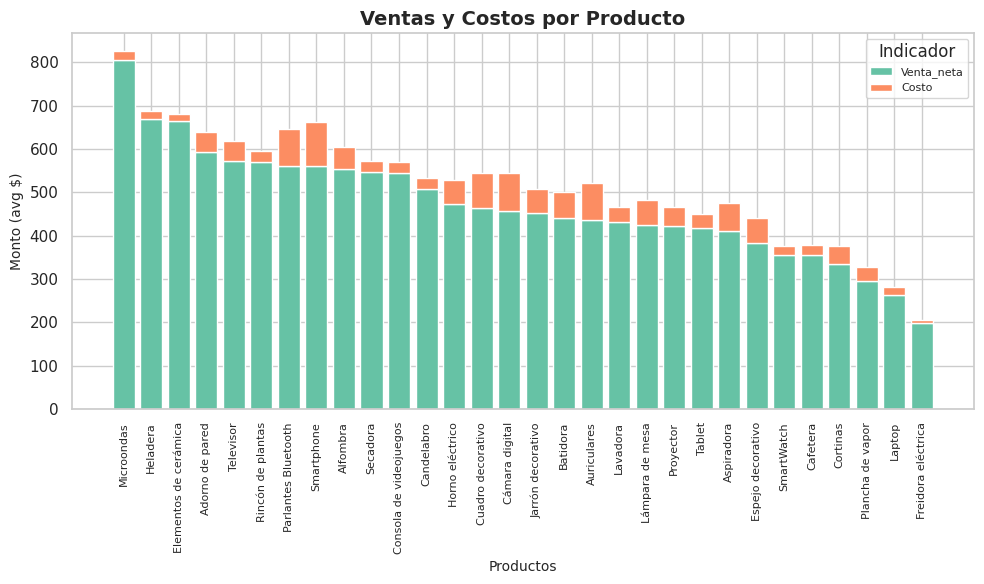

In [69]:
# Generamos un gráfico de barras apilado, de manera de mostrar comparativamente
# las ganancias sobre las ventas
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo y paleta
sns.set_theme(style="whitegrid", palette="Set2")
plt.figure(figsize=(8,5))


# Creamos el gráfico apilado
plt.figure(figsize=(10,6))
plt.bar(
   df_ventas_rrss_prod_costo_activa["producto"],
    df_ventas_rrss_prod_costo_activa["venta_neta_avg"], label="Venta_neta")

plt.bar(
    df_ventas_rrss_prod_costo_activa["producto"],
    df_ventas_rrss_prod_costo_activa["costo_sum"],
    bottom = df_ventas_rrss_prod_costo_activa["venta_neta_avg"], label="Costo")

# Personalización
plt.title("Ventas y Costos por Producto", fontsize=14, weight="bold")
plt.xlabel("Productos", fontsize=10)
plt.ylabel("Monto (avg $)", fontsize=10)
plt.xticks(rotation=90, fontsize=8)

plt.legend(title="Indicador", fontsize=8)

plt.tight_layout()
plt.show()

###Gráficos con Plotly

In [70]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [71]:
# Ventas promedio dentro y fuera de campaña RRSS
kpi_ventas = (
    df_ventas_rrss
    .groupby("en_campanha", as_index=False)
    .agg(venta_neta_avg=("venta_neta", "mean"))
)

venta_prom_en_campanha = kpi_ventas.loc[
    kpi_ventas["en_campanha"] == True,
    "venta_neta_avg"
].iloc[0]

venta_prom_fuera_campanha = kpi_ventas.loc[
    kpi_ventas["en_campanha"] == False,
    "venta_neta_avg"
].iloc[0]

# Costos de marketing solo RRSS
costo_marketing_rrss = df_marketing_canal["costo"].sum()

fig_kpis = make_subplots(
    rows=1,
    cols=3,
    specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}]]
)

fig_kpis.add_trace(
    go.Indicator(
        mode="number",
        value=venta_prom_en_campanha,
        title={"text": "Venta promedio<br>En campaña"},
        number={"prefix": "$", "valueformat": ",.2f"}
    ),
    row=1, col=1
)

fig_kpis.add_trace(
    go.Indicator(
        mode="number",
        value=venta_prom_fuera_campanha,
        title={"text": "Venta promedio<br>Fuera de campaña"},
        number={"prefix": "$", "valueformat": ",.2f"}
    ),
    row=1, col=2
)

fig_kpis.add_trace(
    go.Indicator(
        mode="number",
        value=costo_marketing_rrss,
        title={"text": "Costo marketing<br>RRSS"},
        number={"prefix": "$", "valueformat": ",.2f"}
    ),
    row=1, col=3
)

fig_kpis.update_layout(
    title="KPIs generales - Campañas RRSS",
    height=280
)

fig_kpis.show()

In [73]:
fig_line = px.line(
    df_ventas_rrss_time,
    x="month",
    y="ventas_promedio",
    color="estado",
    markers=True,
    title="Evolución mensual de la venta promedio - RRSS",
    labels={
        "month": "Mes",
        "ventas_promedio": "Venta promedio ($)",
        "estado": "Estado"
    }
)

fig_line.update_layout(
    template="plotly_white",
    legend_title_text="Estado",
    xaxis=dict(dtick=1),
    height=500
)

fig_line.show()

In [74]:
fig_bar1 = px.bar(
    df_ventas_rrss_prod,
    x="producto",
    y="venta_neta_avg",
    color="estado",
    barmode="group",
    category_orders={"producto": orden3}, # ajustar para ordenar los datos
    title="Venta promedio por producto: en campaña vs fuera de campaña - RRSS",
    labels={
        "producto": "Producto",
        "venta_neta_avg": "Venta promedio ($)",
        "estado": "Estado"
    },
    template="plotly_white",
    color_discrete_map={                                     # ← agregado
        "En campaña": "#4C78A8",   # ajustá el nombre exacto de tus métricas
        "Fuera de campaña": "#F58518"
    }
)

fig_bar1.update_layout(
    template="plotly_white",
    height=550,
    xaxis_tickangle=-45,
    legend_title_text="Estado"
)

fig_bar1.show()

In [75]:
fig_bar2 = px.bar(
   df_ventas_rrss_prod_costo_activa_long,
    x="producto",
    y="valor",
    color="metrica",
    barmode="group",
    title="Venta promedio y costo de marketing por producto - Campañas RRSS activas",
    labels={
        "producto": "Producto",
        "valor": "Monto ($)",
        "metrica": "Métrica"
    },
    template="plotly_white",
    color_discrete_map={                                     # ← agregado
        "venta_neta_avg": "#4C78A8",   # ajustá el nombre exacto de tus métricas
        "costo_sum": "#F58518"
    }
)

fig_bar2.update_layout(
    template="plotly_white",
    height=550,
    xaxis_tickangle=-45,
    legend_title_text="Métrica"
)

# Botones para alternar entre modo agrupado y apilado
fig_bar2.update_layout(
    updatemenus=[dict(
        type="buttons",
        direction="right",
        x=1.0, y=1.15,
        showactive=True,
        buttons=[
            dict(label="Agrupado", method="relayout", args=[{"barmode": "group"}]),
            dict(label="Apilado",  method="relayout", args=[{"barmode": "stack"}]),
        ]
    )]
)

fig_bar2.show()

#Exportar gráficos en HTML


In [81]:
html_lineplot = fig_line.to_html(full_html=False, include_plotlyjs="cdn")
# html_lineplot

In [80]:
html_barplot1 = fig_bar1.to_html(full_html=False, include_plotlyjs="cdn")
# html_barplot1

In [79]:
html_barplot2 = fig_bar2.to_html(full_html=False, include_plotlyjs="cdn")
# html_barplot2